In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})


# Total Chemical Potential

The total chemical potential in a fluid is given by:

$\mu = \mu_\text{id} + \mu_\text{ex}$

- $\mu_\text{id}$ is the ideal gas contribution,
- $\mu_\text{ex}$ is the excess chemical potential due to
    intermolecular interactions.

# Ideal Gas Contribution

The ideal gas chemical potential is:

$\mu_\text{id} = k_B T \ln(\rho \Lambda^3)$

where $\rho = N/V$ is the number density and $\Lambda$ is the thermal de Broglie wavelength:

$\Lambda = \sqrt{\frac{h^2}{2 \pi m k_B T}}$

- $h = 6.626 \times 10^{-34}\ \mathrm{J\ s}$ (Planck's constant),
- $m = \frac{44.01\ \mathrm{g/mol}}{6.022 \times 10^{23}}\approx 7.308\times 10^{-26}\ \mathrm{kg}$ (mass of one CO2 molecule),
- $k_B = 1.3806 \times 10^{-23}\ \mathrm{J/K}$ (Boltzmann constant),
- $T = 300$ K.

$\to \Lambda = 0.152 \mathrm{\AA{}}$

In [20]:
mu_vs_N_gcmc_lammps = np.loadtxt("GCMC-LAMMPS/number_vs_mu.dat")
mu_vs_N_gcmc_maniac = np.loadtxt("GCMC-MANIAC/number_vs_mu.dat")
muex_vs_N_widom_lammps = np.loadtxt("Widom-LAMMPS/number_vs_muex.dat")
muex_vs_N_widom_maniac = np.loadtxt("Widom-MANIAC/number_vs_muex.dat")

In [21]:
Lambda = 0.152e-10 # de Broglie wavelenght in m for CO2 at 300 K
T = 300 # K
kB = 1.987e-3 # kcal/mol/K
V = (40e-10)**3 # volume in m3

In [22]:
MANIAC = r'MANIAC (v0.3.5-beta)'
LAMMPS = r'LAMMPS (22 Jul 2025)'

In [23]:
# Ideal gas guide
mu_ig = np.linspace(-10.2, -6.8, 300)   # kcal/mol
rho_ig = np.exp(mu_ig / (kB * T)) / Lambda**3

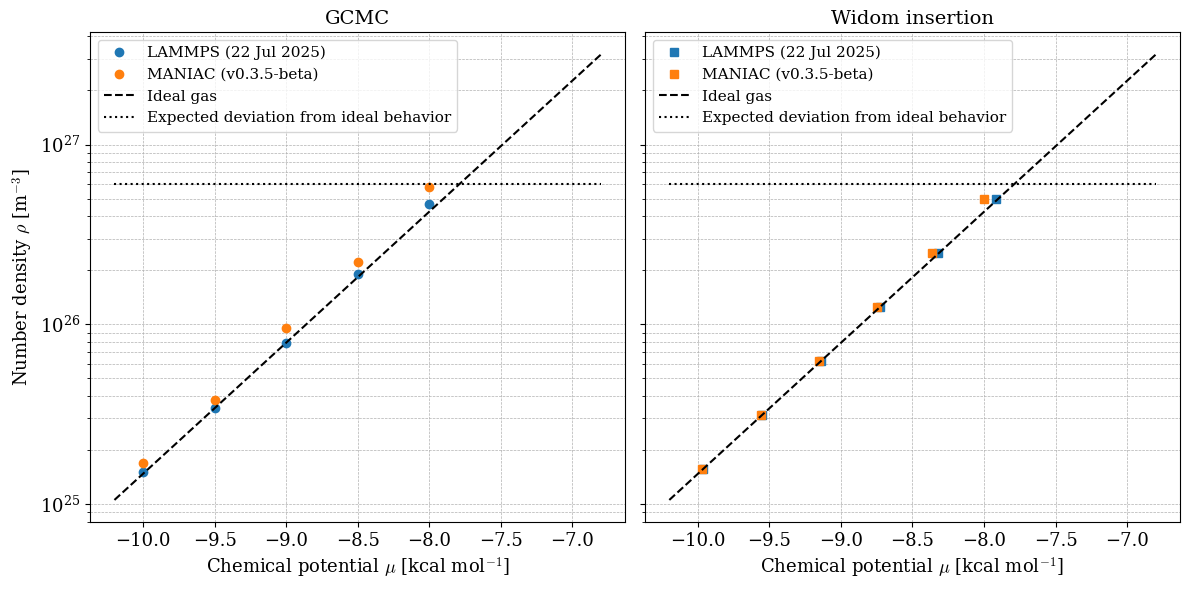

In [24]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6), sharey=True)

# LEFT PANEL — GCMC
ax = axes[0]

# LAMMPS
N = mu_vs_N_gcmc_lammps[:,1]
mu = mu_vs_N_gcmc_lammps[:,0]
rho = N / V
ax.semilogy(mu, rho, 'o', label=LAMMPS, markersize=6)

# MANIAC
N = mu_vs_N_gcmc_maniac[:,1]
mu = mu_vs_N_gcmc_maniac[:,0]
rho = N / V
ax.semilogy(mu, rho, 'o', label=MANIAC, markersize=6)

# Ideal gas guide
ax.semilogy(mu_ig, rho_ig, '--', color='black', linewidth=1.5, label=r'Ideal gas')
ax.semilogy(mu_ig, mu_ig*0+6e26, ':', color='black', linewidth=1.5, label=r'Expected deviation from ideal behavior')

ax.set_xlabel(r'Chemical potential $\mu$ [kcal mol$^{-1}$]', fontsize=13)
ax.set_ylabel(r'Number density $\rho$ [m$^{-3}$]', fontsize=13)
ax.set_title(r'GCMC', fontsize=14)
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend(fontsize=11)

# RIGHT PANEL — WIDOM
ax = axes[1]

# LAMMPS
N = muex_vs_N_widom_lammps[:,1]
mu_ex = muex_vs_N_widom_lammps[:,0]
rho = N / V
mu_id = kB * T * np.log(rho * Lambda**3)
mu = mu_id + mu_ex

ax.semilogy(mu, rho, 's', label=LAMMPS, markersize=6)

# MANIAC
N = muex_vs_N_widom_maniac[:,1]
mu_ex = muex_vs_N_widom_maniac[:,0]
rho = N / V
mu_id = kB * T * np.log(rho * Lambda**3)
mu = mu_id + mu_ex

ax.semilogy(mu, rho, 's', label=MANIAC, markersize=6)

# Ideal gas guide
ax.semilogy(mu_ig, rho_ig, '--', color='black', linewidth=1.5, label=r'Ideal gas')
ax.semilogy(mu_ig, mu_ig*0+6e26, ':', color='black', linewidth=1.5, label=r'Expected deviation from ideal behavior')

ax.set_xlabel(r'Chemical potential $\mu$ [kcal mol$^{-1}$]', fontsize=13)
ax.set_title(r'Widom insertion', fontsize=14)
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend(fontsize=11)

# FINAL
plt.tight_layout()
plt.savefig("Maniac_vs_LAMMPS.png", dpi=300)
plt.show()
